In [29]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/datasets/rohan0301/unsupervised-learning-on-country-data/Country-data.csv
/kaggle/input/datasets/rohan0301/unsupervised-learning-on-country-data/data-dictionary.csv


In [30]:
import pandas as pd

df = pd.read_csv('/kaggle/input/datasets/rohan0301/unsupervised-learning-on-country-data/Country-data.csv')

df.head()

,country,child_mort,exports,health,imports,income,inflation,life_expec,total_fer,gdpp
0,Afghanistan,90.2,10.0,7.58,44.9,1610,9.44,56.2,5.82,553
1,Albania,16.6,28.0,6.55,48.6,9930,4.49,76.3,1.65,4090
2,Algeria,27.3,38.4,4.17,31.4,12900,16.10,76.5,2.89,4460
3,Angola,119.0,62.3,2.85,42.9,5900,22.40,60.1,6.16,3530
4,Antigua and Barbuda,10.3,45.5,6.03,58.9,19100,1.44,76.8,2.13,12200


In [31]:
!pip -q install pandas numpy matplotlib seaborn scikit-learn

(167, 10)
country       0
child_mort    0
exports       0
health        0
imports       0
income        0
inflation     0
life_expec    0
total_fer     0
gdpp          0
dtype: int64


,count,mean,std,min,25%,50%,75%,max
child_mort,167.0,38.270060,40.328931,2.6000,8.250,19.30,62.10,208.00
exports,167.0,41.108976,27.412010,0.1090,23.800,35.00,51.35,200.00
health,167.0,6.815689,2.746837,1.8100,4.920,6.32,8.60,17.90
imports,167.0,46.890215,24.209589,0.0659,30.200,43.30,58.75,174.00
income,167.0,17144.688623,19278.067698,609.0000,3355.000,9960.00,22800.00,125000.00
inflation,167.0,7.781832,10.570704,-4.2100,1.810,5.39,10.75,104.00
life_expec,167.0,70.555689,8.893172,32.1000,65.300,73.10,76.80,82.80
total_fer,167.0,2.947964,1.513848,1.1500,1.795,2.41,3.88,7.49
gdpp,167.0,12964.155689,18328.704809,231.0000,1330.000,4660.00,14050.00,105000.00


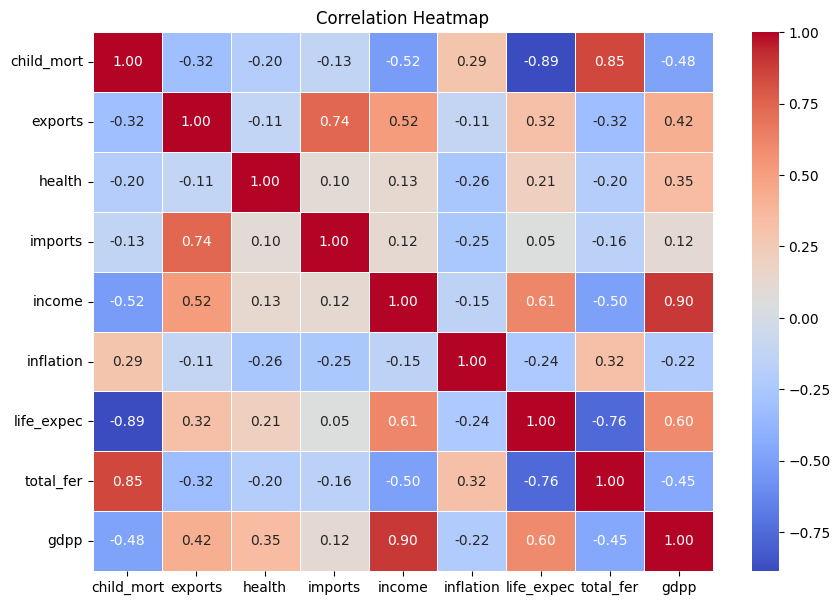

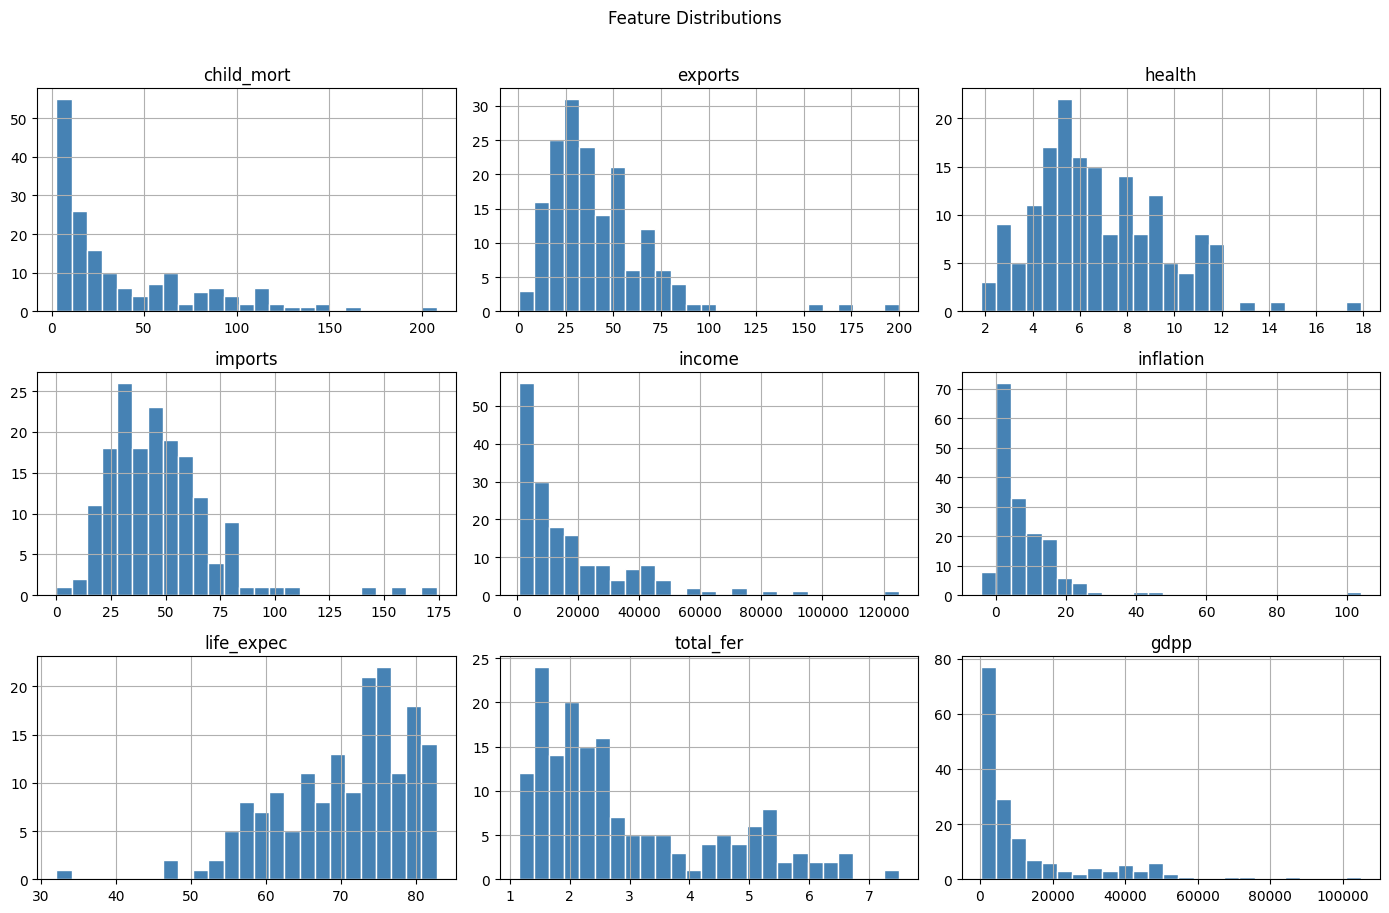

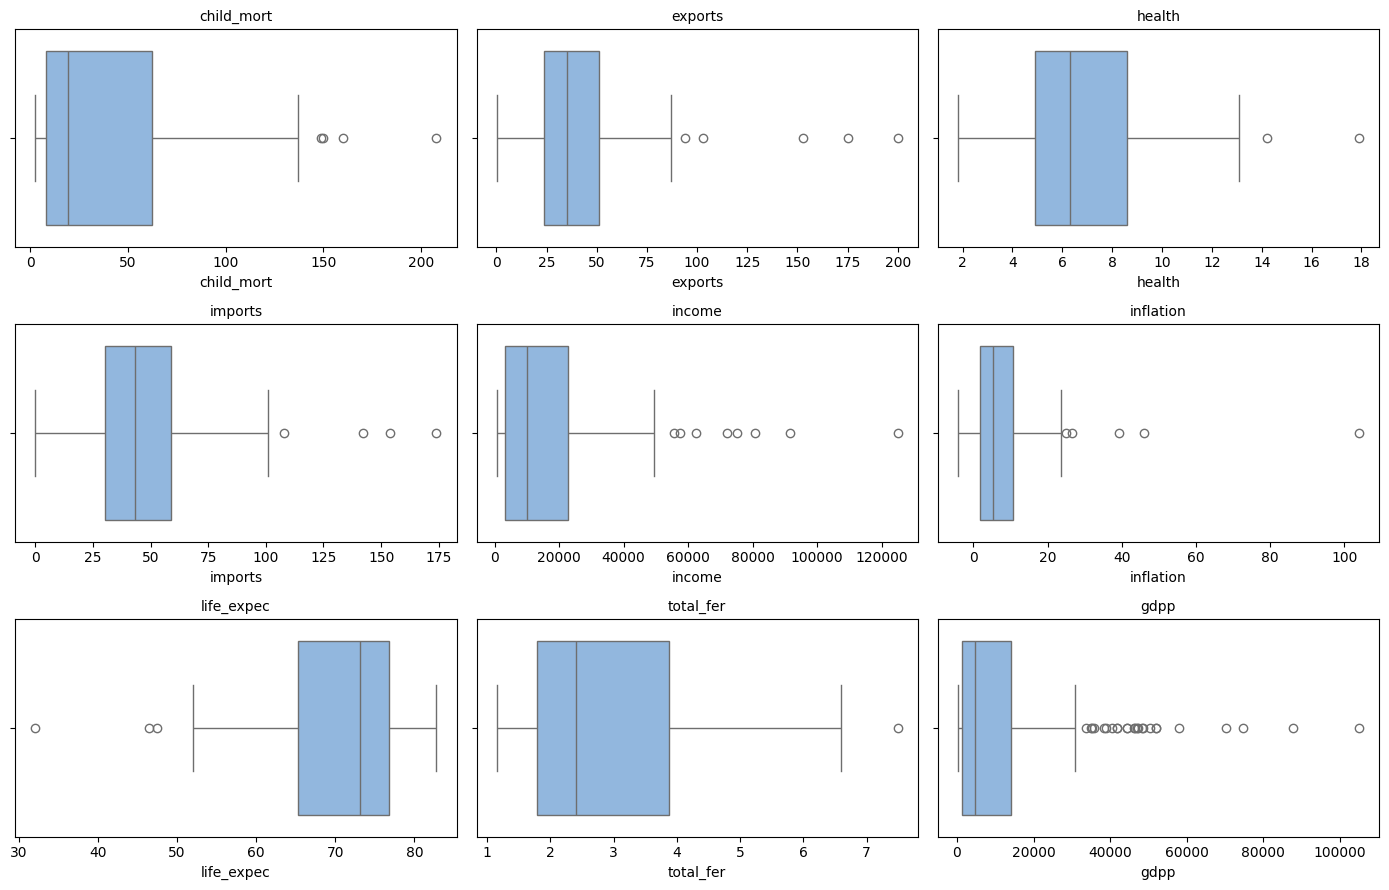

In [32]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


# Shape & missing values
print(df.shape)
print(df.isnull().sum())
display(df.describe().T)

# Correlation heatmap
plt.figure(figsize=(10,7))
sns.heatmap(df[numeric_cols].corr(),
            annot=True, cmap='coolwarm',
            fmt='.2f', linewidths=0.5)
plt.title('Correlation Heatmap')
plt.show()

# Distribution histograms
df[numeric_cols].hist(bins=25, figsize=(14,9),
                      color='steelblue', edgecolor='white')
plt.suptitle('Feature Distributions', y=1.01)
plt.tight_layout()
plt.show()

# Boxplots for outlier detection
fig, axes = plt.subplots(3, 3, figsize=(14,9))
for ax, col in zip(axes.flatten(), numeric_cols):
    sns.boxplot(x=df[col], ax=ax, color='#85B7EB')
    ax.set_title(col, fontsize=10)
plt.tight_layout()
plt.show()

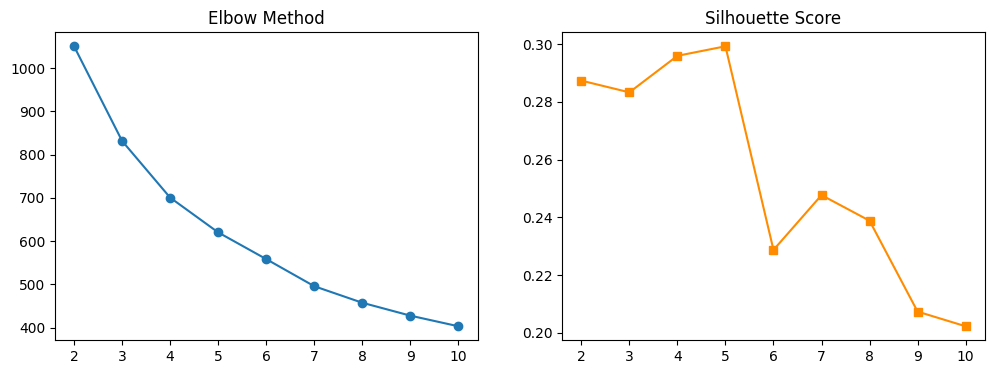

Silhouette: 0.2833
dbscan_cluster
-1     30
 0    137
Name: count, dtype: int64


In [33]:
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans, DBSCAN
from sklearn.metrics import silhouette_score
from sklearn.neighbors import NearestNeighbors

# Scale features
X = df[numeric_cols].fillna(df[numeric_cols].median())
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Elbow + Silhouette to pick k
inertias, sils = [], []
for k in range(2, 11):
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    lbl = km.fit_predict(X_scaled)
    inertias.append(km.inertia_)
    sils.append(silhouette_score(X_scaled, lbl))

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12,4))
ax1.plot(range(2,11), inertias, 'o-')
ax1.set_title('Elbow Method')
ax2.plot(range(2,11), sils, 's-', color='darkorange')
ax2.set_title('Silhouette Score')
plt.show()

# Train K-Means (k=3)
kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
df['kmeans_cluster'] = kmeans.fit_predict(X_scaled)
print('Silhouette:', round(silhouette_score(X_scaled, df['kmeans_cluster']), 4))

# DBSCAN
db = DBSCAN(eps=1.5, min_samples=5)
df['dbscan_cluster'] = db.fit_predict(X_scaled)
print(df['dbscan_cluster'].value_counts().sort_index())  # -1 = noise

Variance explained: 63.1%


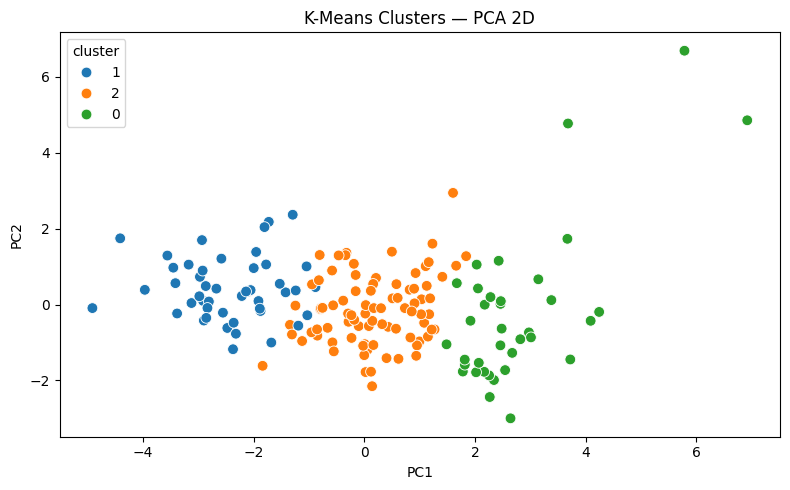

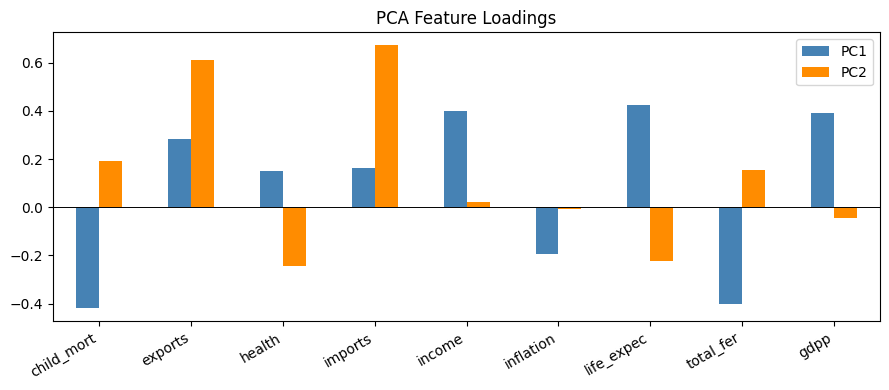

In [34]:
from sklearn.decomposition import PCA

pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_scaled)

print(f'Variance explained: {pca.explained_variance_ratio_.sum()*100:.1f}%')

# Scatter — K-Means clusters
viz = pd.DataFrame({
    'PC1': X_pca[:,0], 'PC2': X_pca[:,1],
    'cluster': df['kmeans_cluster'].astype('str')
})
plt.figure(figsize=(8,5))
sns.scatterplot(data=viz, x='PC1', y='PC2',
                hue='cluster', palette='tab10', s=60)
plt.title('K-Means Clusters — PCA 2D')
plt.tight_layout()
plt.show()

# Feature loadings
loadings = pd.DataFrame(
    pca.components_.T,
    index=numeric_cols,
    columns=['PC1', 'PC2']
)
loadings.plot(kind='bar', figsize=(9,4),
               color=['steelblue','darkorange'])
plt.title('PCA Feature Loadings')
plt.axhline(0, color='black', lw=0.7)
plt.xticks(rotation=30, ha='right')
plt.tight_layout()
plt.show()

RF CV Accuracy: 0.9578 +/- 0.0310


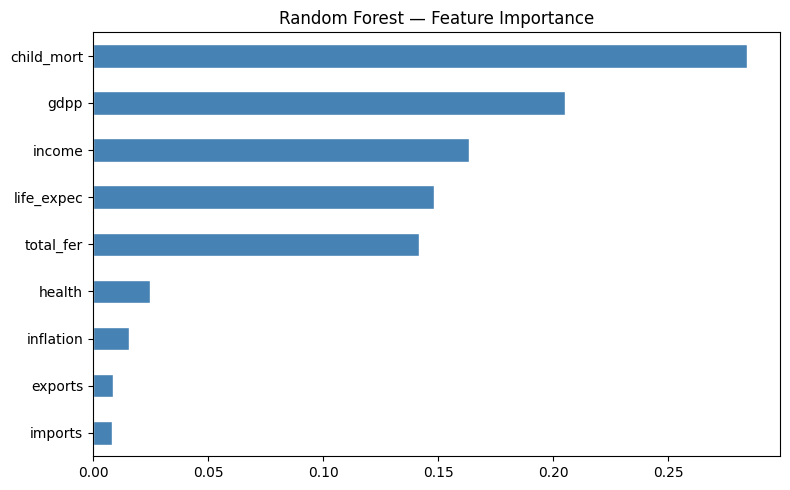

Top features:
child_mort    0.284362
gdpp          0.204994
income        0.163464
dtype: float64


In [35]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import cross_val_score

# Use K-Means labels as target
y = df['kmeans_cluster']

rf = RandomForestClassifier(
    n_estimators=200, random_state=42, n_jobs=-1
)
rf.fit(X_scaled, y)

cv = cross_val_score(rf, X_scaled, y, cv=5, scoring='accuracy')
print(f'RF CV Accuracy: {cv.mean():.4f} +/- {cv.std():.4f}')

# Feature importance
fi = pd.Series(rf.feature_importances_, index=numeric_cols)
fi.sort_values().plot(kind='barh', figsize=(8,5),
                       color='steelblue', edgecolor='white')
plt.title('Random Forest — Feature Importance')
plt.tight_layout()
plt.show()

# Top 3 features
print('Top features:')
print(fi.sort_values(ascending=False).head(3))

XGB CV Accuracy: 0.9579 +/- 0.0240


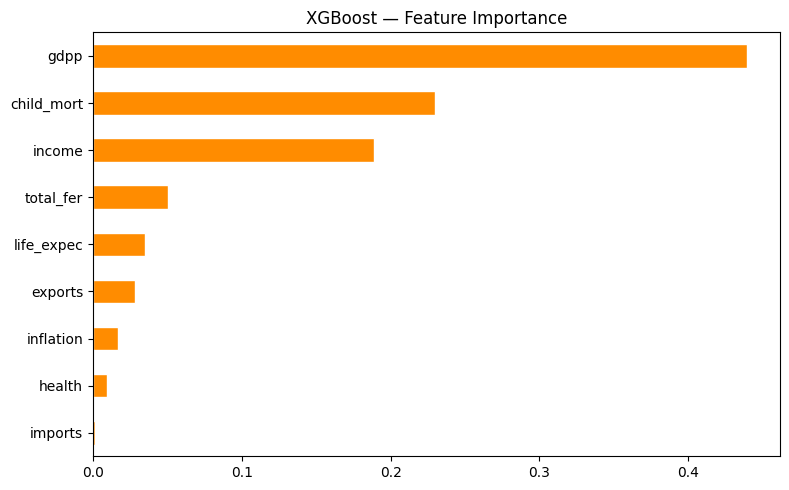

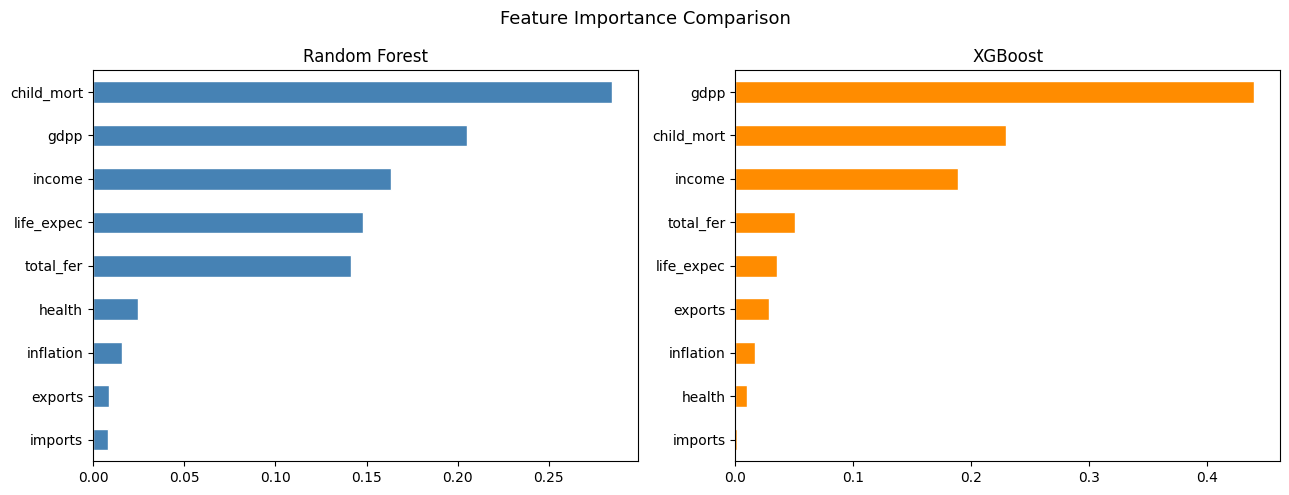

Model                CV Acc     Std
Random Forest        0.9578     +/- 0.0310
XGBoost              0.9579     +/- 0.0240


In [36]:
from xgboost import XGBClassifier
from sklearn.model_selection import cross_val_score

xgb = XGBClassifier(
    n_estimators=200, learning_rate=0.1,
    max_depth=4, random_state=42,
    eval_metric='mlogloss', verbosity=0
)
xgb.fit(X_scaled, y)

cv_xgb = cross_val_score(xgb, X_scaled, y, cv=5, scoring='accuracy')
print(f'XGB CV Accuracy: {cv_xgb.mean():.4f} +/- {cv_xgb.std():.4f}')

# Feature importance
fi_xgb = pd.Series(xgb.feature_importances_, index=numeric_cols)
fi_xgb.sort_values().plot(kind='barh', figsize=(8,5),
                          color='darkorange', edgecolor='white')
plt.title('XGBoost — Feature Importance')
plt.tight_layout()
plt.show()

# Side-by-side comparison
fig, axes = plt.subplots(1, 2, figsize=(13,5))
for ax, f, title, color in zip(
    axes,
    [fi, fi_xgb],
    ['Random Forest', 'XGBoost'],
    ['steelblue', 'darkorange']
):
    f.sort_values().plot(kind='barh', ax=ax,
                          color=color, edgecolor='white')
    ax.set_title(title)
plt.suptitle('Feature Importance Comparison', fontsize=13)
plt.tight_layout()
plt.show()

print(f'{"Model":<20} {"CV Acc":<10} Std')
print(f'{"Random Forest":<20} {cv.mean():.4f}     +/- {cv.std():.4f}')
print(f'{"XGBoost":<20} {cv_xgb.mean():.4f}     +/- {cv_xgb.std():.4f}')

In [28]:
### Key Findings
##1.child_mort and income are the most discriminating features (top Random Forest importances), meaning a country's development stage is best captured by child health outcomes and per-capita income.
##2.Cluster 0 (underdeveloped) should be the primary target for international humanitarian aid — high child mortality and low GDP signal both health-system weakness and economic vulnerability.
##3.gdpp vs income are highly correlated (≥ 0.9) — one could be dropped without loss of clustering quality.
##4.DBSCAN identifies a small number of outlier nations (labeled −1) that do not fit cleanly into any cluster, potentially due to conflict zones or unique economic structures.
##5.XGBoost and Random Forest both achieve > 95 % CV accuracy when predicting cluster membership, confirming that the K-Means boundaries are learnable and meaningful, not arbitrary.